In [1]:
import os
import xarray as xr
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from shared_read_HBR import *
from matplotlib import rcParams
from matplotlib.patches import Patch

#site = 'HBR'
#prefix = '20250113'
#prefix = '20250210'
#suffix = '3year_rmethod1_testRainVert' # _VertOMappCtrl
#prefix = '20250427'
#suffix = '3year_rmethod1_appCtrl'
#suffix = '1year_rmethod1_1cm'
#suffix = '10year_5cm_multInit_FMAX'
site = 'UIEF'
prefix = '20250612'
suffix = '10year'

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

elm_thickness = np.diff(np.array([0, 1.75, 4.51, 9.06, 16.55, 28.91, 49.29, 82.89, 138.28]))

In [2]:
flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 
                        f'{prefix}_{site}_ICB20TRCNPRDCTCBC_{suffix}erw', 'run', 
                        f'{prefix}_{site}_ICB20TRCNPRDCTCBC_{suffix}erw.elm.h1.{yy}-01-01-00000.nc') \
            #for yy in range(1980, 2022)]
            for yy in range(1850, 1880)]

hr = xr.open_mfdataset(flist)
tvec = pd.DatetimeIndex([pd.Timestamp(year=t.year, month=t.month, day=t.day) \
                         for t in hr['time'].to_index()])

/tmp/ipykernel_2073002/2167858536.py:33: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  soil_pore_sim = pd.DataFrame(soil_pore_sim).stack()


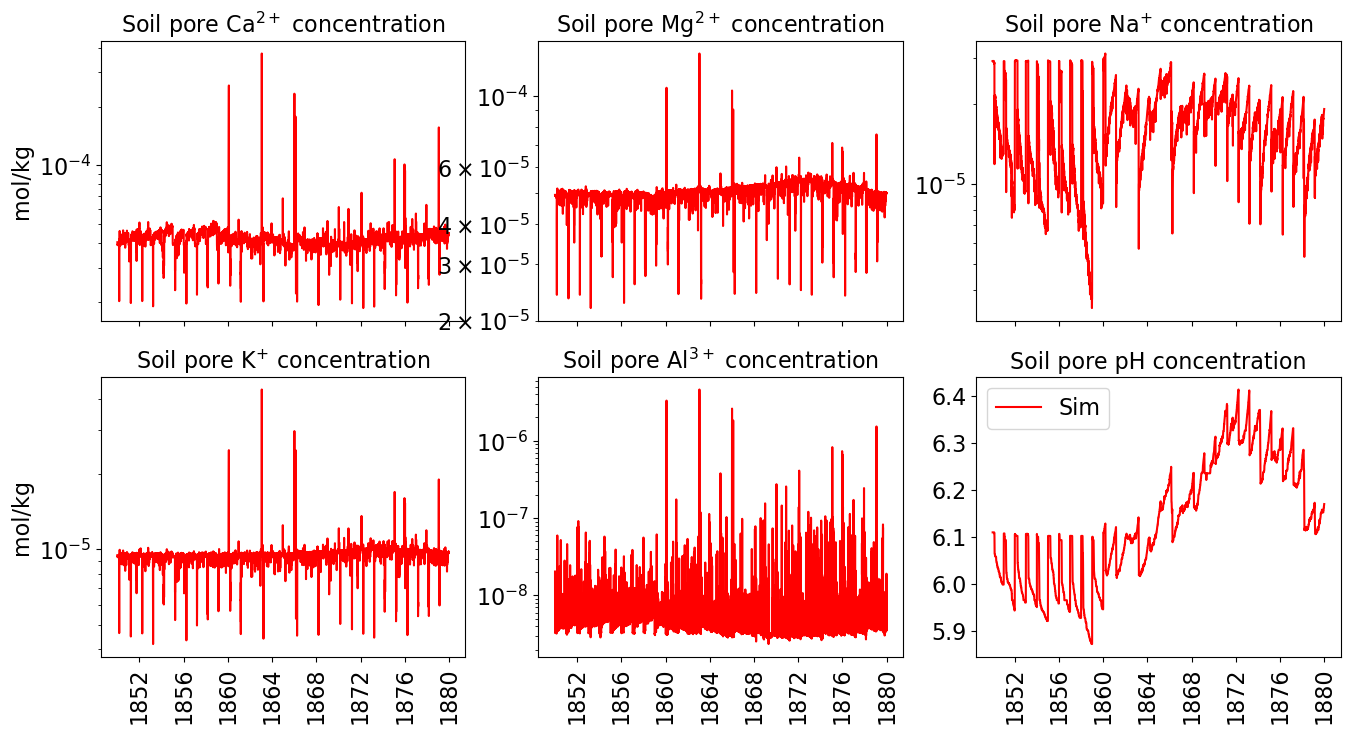

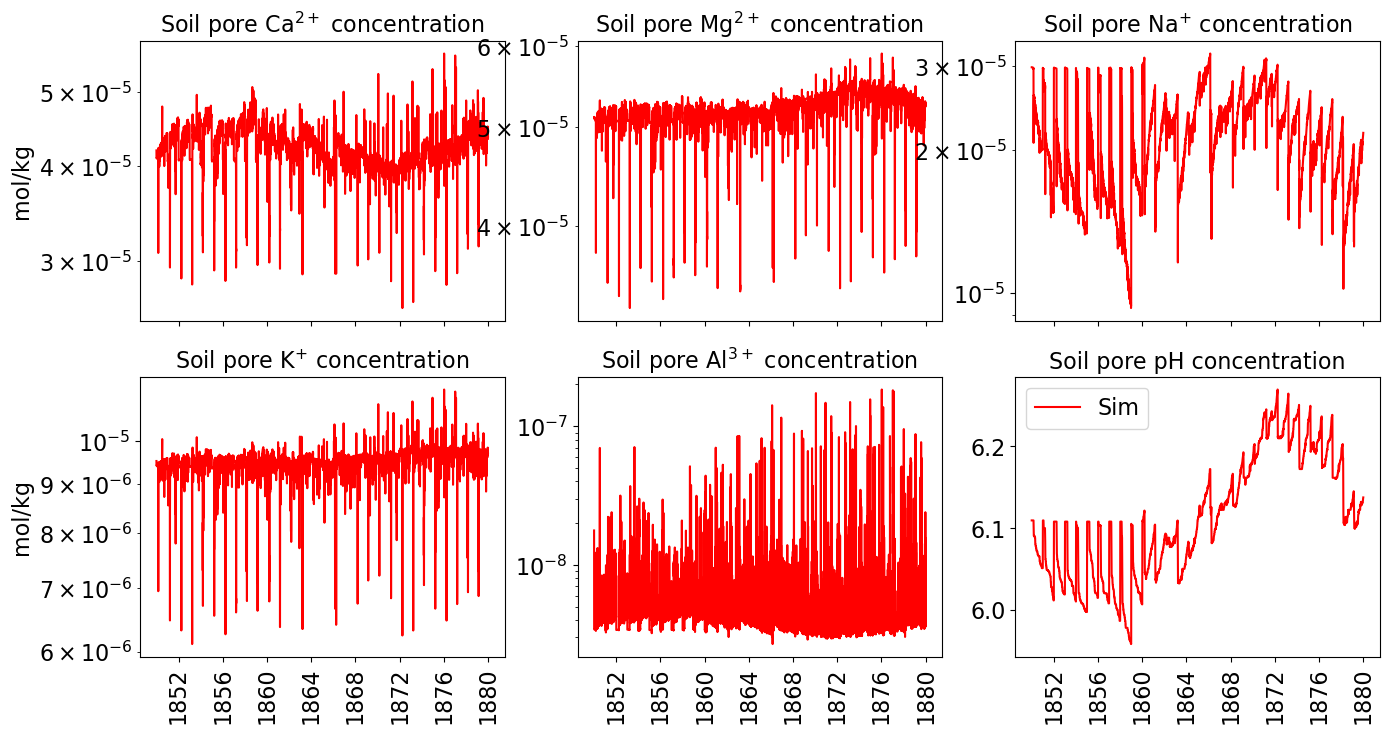

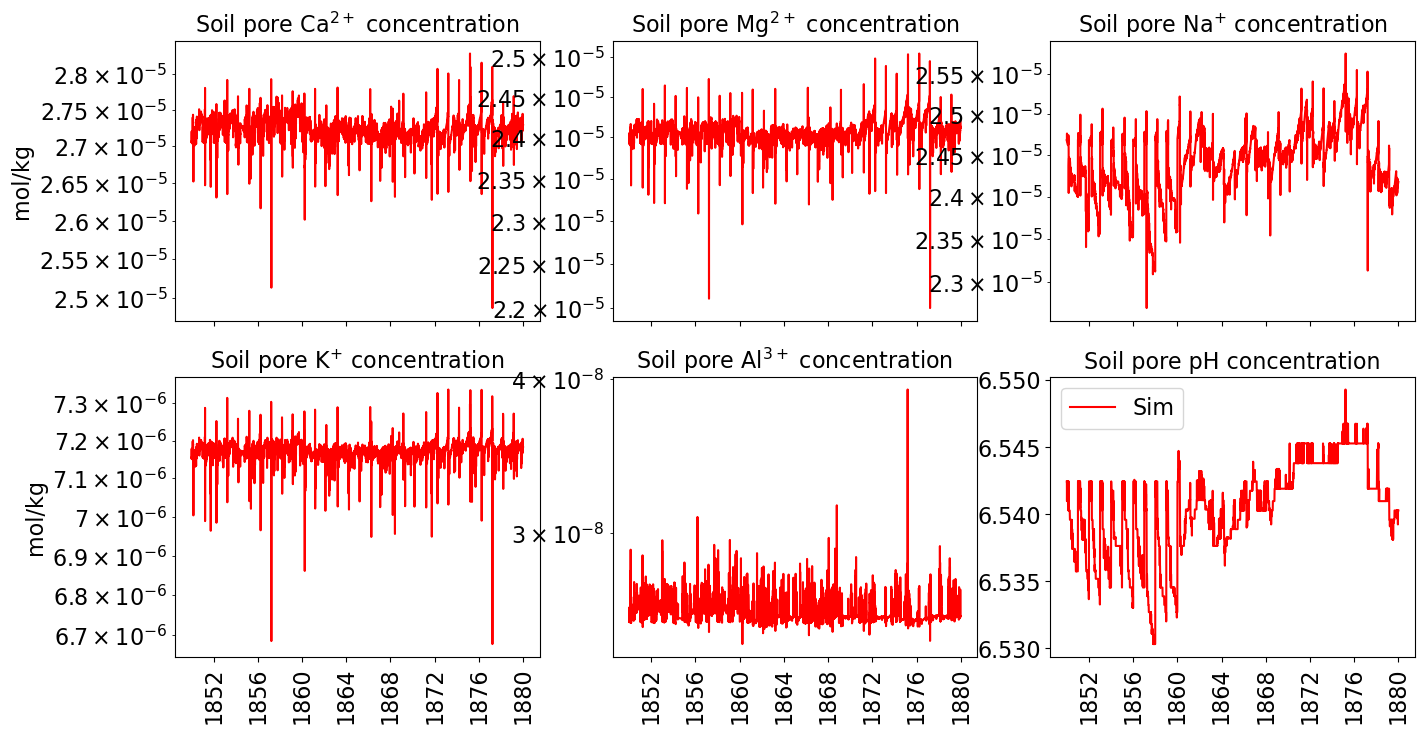

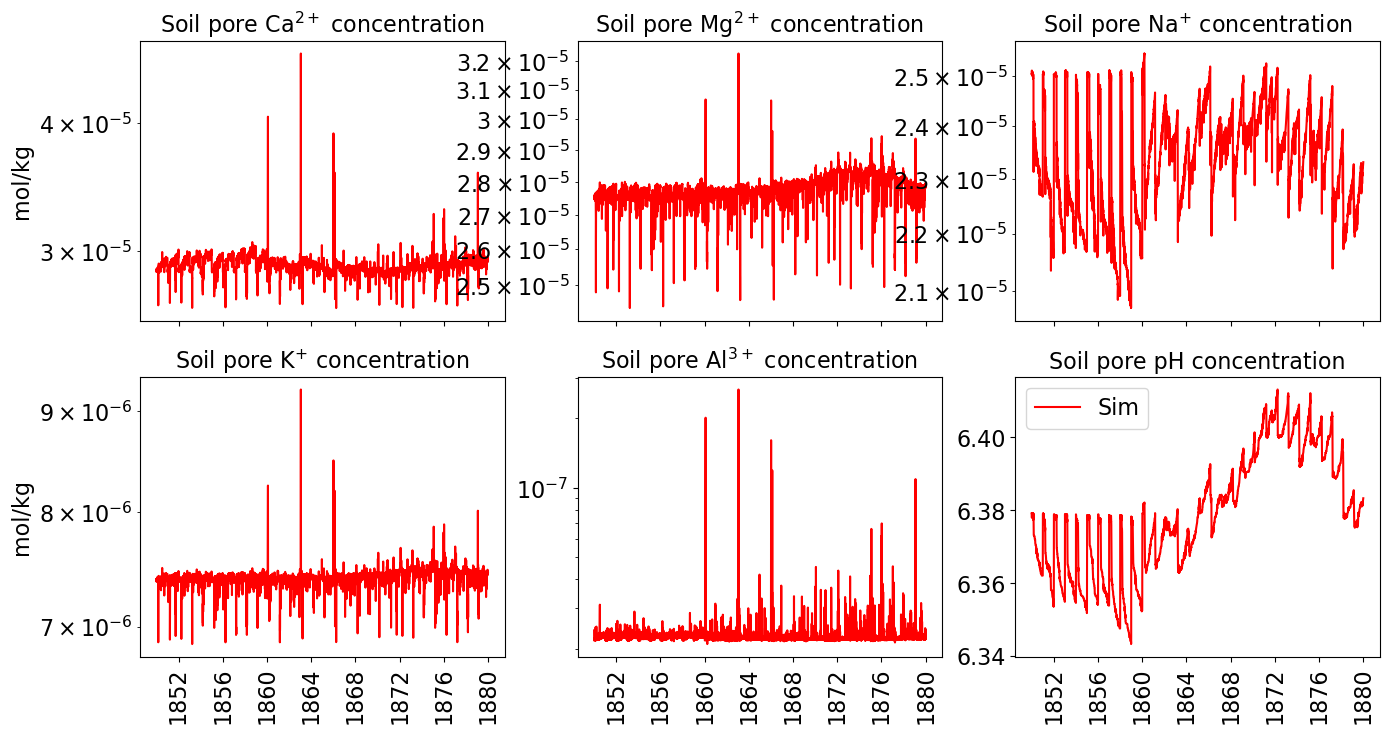

In [3]:
# Layerwise soil pore water cation concentration
# Oe: 0-2.5cm (lacks std in 2020)
# Oa: 2.5-7cm
# B: 20-60cm

# convert from g m-3 soil to mol/kg porewater
soil_pore_sim = {}
for i, (cation, mass_ca) in \
    enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+'], 
                  [40, 24, 23, 29, 27])):
    soil_pore_sim[(cation, 'Oe')] = pd.Series( 
        ((hr[f'cation_vr_{i+1}'][:,:2,0] / hr['H2OSOI'][:,:2,0] / mass_ca / 1000) *
          np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5, 
        index = tvec)
    soil_pore_sim[(cation, 'Oa')] = pd.Series( 
        ((hr[f'cation_vr_{i+1}'][:,1:3,0] / hr['H2OSOI'][:,1:3,0] / mass_ca / 1000) *
          np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) / (7-2.5), 
        index = tvec)
    soil_pore_sim[(cation, 'B')] = pd.Series( 
        ((hr[f'cation_vr_{i+1}'][:,4:6,0] / hr['H2OSOI'][:,4:6,0] / mass_ca / 1000) *
          np.array([28.91-20, 49.29-28.91]).reshape(1,-1)).sum(axis = 1) / (49.29-20), #, 60-49.29, (60-20)
        index = tvec)
soil_pore_sim[('pH', 'Oe')] = pd.Series( 
        (hr[f'soil_pH'][:,:2,0] * np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5, 
        index = tvec)
soil_pore_sim[('pH', 'Oa')] = pd.Series( 
    (hr[f'soil_pH'][:,1:3,0] * np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) / (7-2.5), 
        index = tvec)
soil_pore_sim[('pH', 'B')] = pd.Series( 
    (hr[f'soil_pH'][:,4:6,0] * np.array([28.91-20, 49.29-28.91]).reshape(1,-1) # , 60-49.29
     ).sum(axis = 1) / (49.29-20), # (60-20), 
        index = tvec)
soil_pore_sim = pd.DataFrame(soil_pore_sim).stack()
soil_pore_sim.index = soil_pore_sim.index.reorder_levels([1, 0])
soil_pore_sim = soil_pore_sim.sort_index()

# Show 3-layer integrated modeled outcome too!!!
for layer in ['Oe', 'Oa', 'B', 'OaeB']:
    if layer == 'OaeB':
        sim = (soil_pore_sim.loc['Oe', :] * 0.025 + soil_pore_sim.loc['Oa', :] * 0.045 + 
               soil_pore_sim.loc['B', :] * 0.3929) / (0.4 + 0.025 + 0.045)
    else:
        sim = soil_pore_sim.loc[layer, :]

    fig, axes = plt.subplots(2, 3, figsize = (16, 8), sharex = True)
    for i, (obs_ca, sim_ca, name) in enumerate(
        zip(['Ca2+', 'Mg2+', 'Na+', 'K+', 'Alt', 'pH'],
            ['Ca2+','Mg2+','Na+','K+','Al3+', 'pH'], 
            ['Ca$^{2+}$', 'Mg$^{2+}$', 'Na$^{+}$', 'K$^{+}$', 'Al$^{3+}$', 'pH'])
    ):
        ax = axes.flat[i]
        ax.plot(sim[sim_ca].index, sim[sim_ca], '-r', label = 'Sim')

        ax.set_xlabel('')
        if np.mod(i, 3) == 0:
            ax.set_ylabel('mol/kg')
        if sim_ca != 'pH':
            ax.set_yscale('log')
        ax.set_title(f'Soil pore {name} concentration')
        plt.setp(ax.get_xticklabels(), rotation = 90)
        # ax.set_xlim([index[25], index[45]])

        #ax.set_xlim(sim[sim_ca].index[0], sim[sim_ca].index[1095])
        #ax.set_xlim(sim[sim_ca].index[1095], sim[sim_ca].index[2190])

    ax.legend(ncol = 2)

/tmp/ipykernel_2073002/2237219879.py:47: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  soil_cec_sim = pd.DataFrame(soil_cec_sim, index = tvec).resample('1Y').mean()
/tmp/ipykernel_2073002/2237219879.py:49: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  soil_cec_sim = soil_cec_sim.stack()


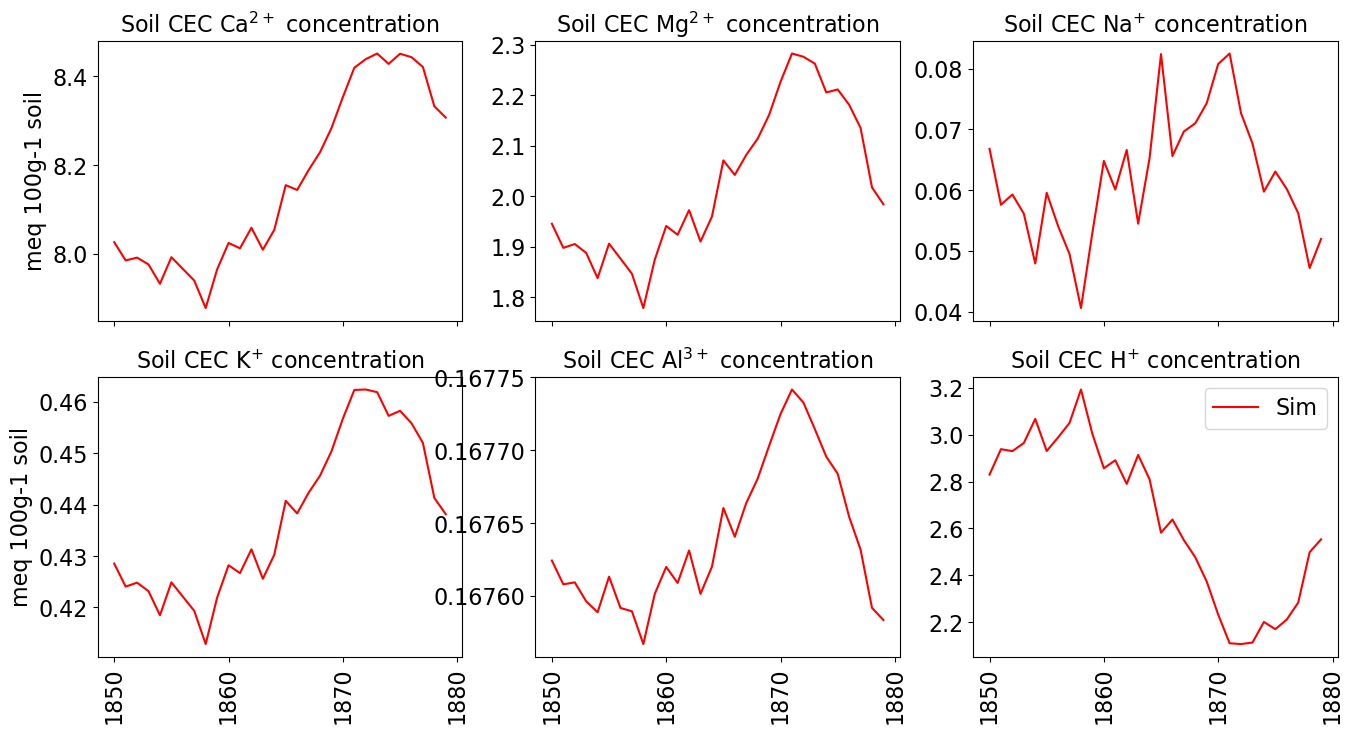

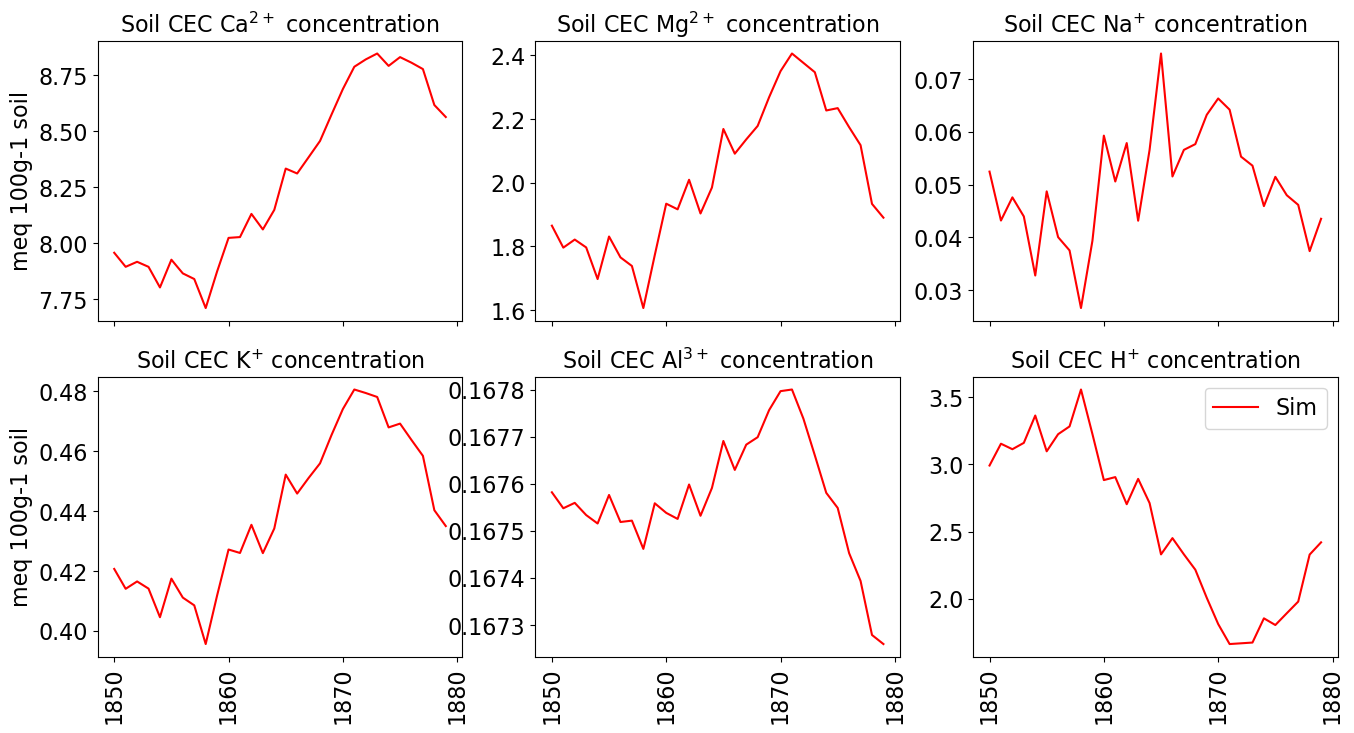

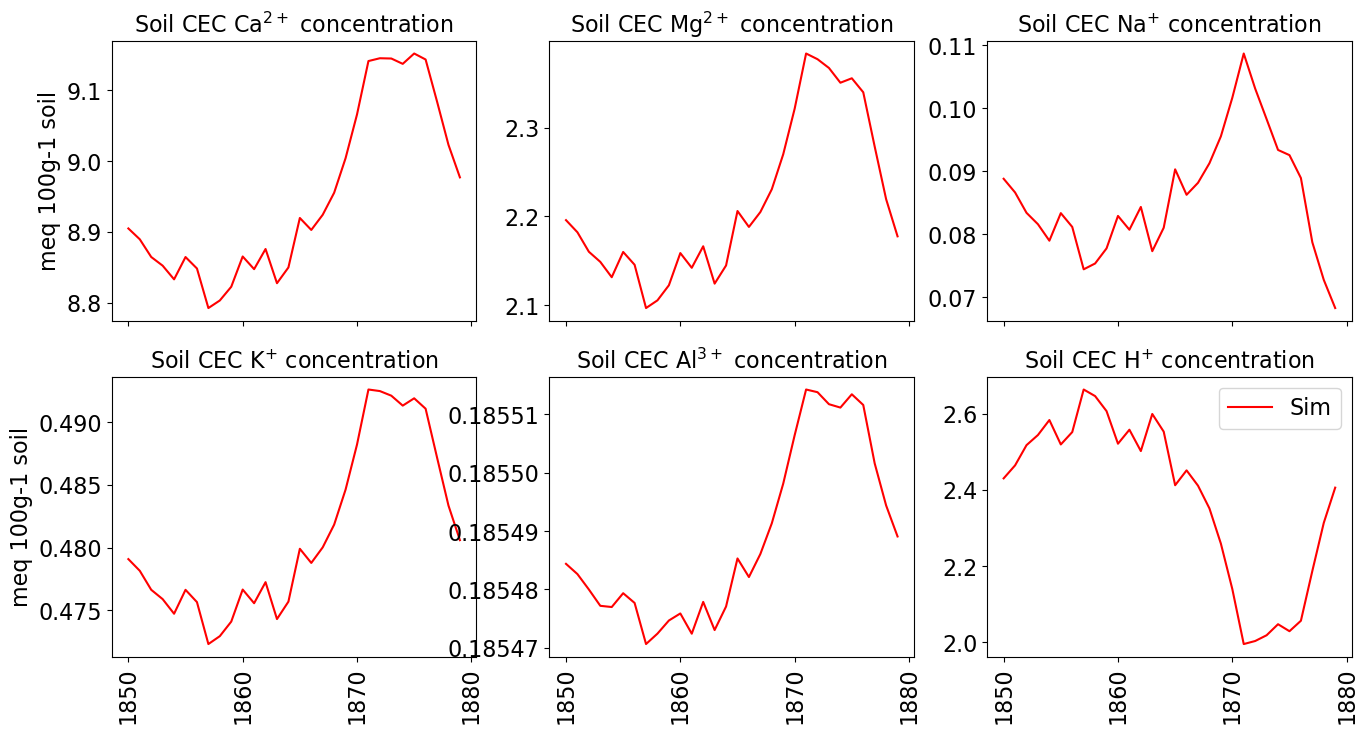

In [4]:
# Layerwise soil CEC background replenishment
# Oe: 0-2.5cm (lacks std in 2020)
# Oa: 2.5-7cm
# B: 20-60cm

# calcium: convert from g m-3 soil to meq 100g-1 dry soil
soil_cec_sim = {}
for i, (cation, val_icat, mass_icat) in \
    enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+'], 
                  [2, 2, 1, 1, 3],
                  [40, 24, 23, 29, 27])):

    soil_cec_sim[(cation, 'Oie')] = \
        (hr[f'cec_cation_vr_{i+1}'][:,:2,0].values * \
         np.array([1.75,2.5-1.75]).reshape(1,-1)).sum(axis = 1) * \
        1000 * val_icat / mass_icat / 10 / \
        (hr['bd_col'][:,:2,0].values * np.array([1.75,2.5-1.75]).reshape(1,-1)
        ).sum(axis = 1)

    soil_cec_sim[(cation, 'Oa')] = \
        (hr[f'cec_cation_vr_{i+1}'][:,1:3,0].values * \
         np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) * \
        1000 * val_icat / mass_icat / 10 / \
        (hr['bd_col'][:,1:3,0].values * np.array([4.51-2.5, 7-4.51]).reshape(1,-1)
        ).sum(axis = 1)

    soil_cec_sim[(cation, 'Min')] = \
        hr[f'cec_cation_vr_{i+1}'][:,3,0].values * 1000 * val_icat / mass_icat / 10 / \
        hr['bd_col'][:,3,0].values

soil_cec_sim[('H+', 'Oie')] = \
    (hr[f'cec_proton_vr'][:,:2,0].values * np.array([1.75,2.5-1.75]).reshape(1,-1)
    ).sum(axis = 1) * 1000 / 10 / \
    (hr['bd_col'][:,:2,0].values * np.array([1.75,2.5-1.75]).reshape(1,-1)
    ).sum(axis = 1)

soil_cec_sim[('H+', 'Oa')] = \
    (hr[f'cec_proton_vr'][:,1:3,0].values * np.array([4.51-2.5, 7-4.51]).reshape(1,-1)
    ).sum(axis = 1) * 1000 / 10 / \
    (hr['bd_col'][:,1:3,0].values * np.array([4.51-2.5, 7-4.51]).reshape(1,-1)
    ).sum(axis = 1)

soil_cec_sim[('H+', 'Min')] = \
    hr[f'cec_proton_vr'][:,3,0].values * 1000 / 10 / \
    hr['bd_col'][:,3,0].values

soil_cec_sim = pd.DataFrame(soil_cec_sim, index = tvec).resample('1Y').mean()
soil_cec_sim.index = soil_cec_sim.index.year
soil_cec_sim = soil_cec_sim.stack()
soil_cec_sim.index = soil_cec_sim.index.reorder_levels([1, 0])
soil_cec_sim = soil_cec_sim.sort_index()

for layer in ['Oa', 'Oie', 'Min']:
    sim = soil_cec_sim.loc[layer, :]

    fig, axes = plt.subplots(2, 3, figsize = (16, 8), sharex = True)
    for i, (sim_ca, name) in enumerate(
        zip(['Ca2+','Mg2+','Na+','K+','Al3+', 'H+'], 
            ['Ca$^{2+}$', 'Mg$^{2+}$', 'Na$^{+}$', 'K$^{+}$', 'Al$^{3+}$', 'H$^{+}$'])
    ):
        ax = axes.flat[i]
        ax.plot(sim[sim_ca].index, sim[sim_ca], '-r', label = 'Sim')

        ax.set_xlabel('')
        if np.mod(i, 3) == 0:
            ax.set_ylabel('meq 100g-1 soil')
        #if sim_ca != 'pH':
        #    ax.set_yscale('log')
        ax.set_title(f'Soil CEC {name} concentration')
        plt.setp(ax.get_xticklabels(), rotation = 90)
        # ax.set_xlim([index[25], index[45]])

    ax.legend(ncol = 2)

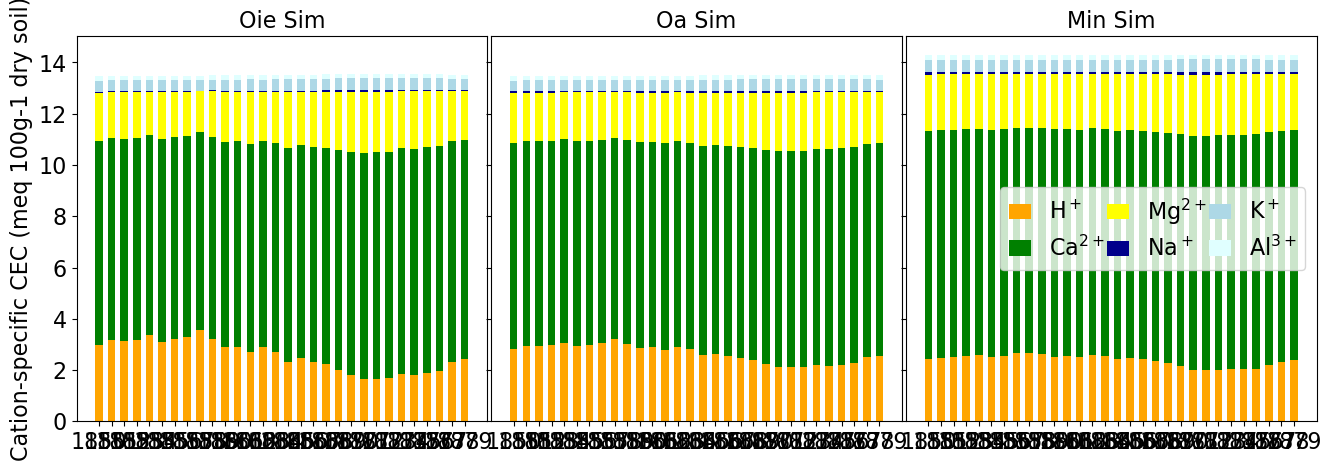

In [5]:
## Convert to beta values (fraction)
cec_sim = soil_cec_sim # / soil_cec_sim.sum(axis = 1).values.reshape(-1, 1)
# re-align the simulation's cation rank
cec_sim = cec_sim.loc[:, ['H+','Ca2+','Mg2+','Na+','K+','Al3+']]


color_list = ['#FFA500', '#008000', '#FFFF00', '#00008B', '#ADD8E6', '#E0FFFF']
name_list = ['H$^+$', 'Ca$^{2+}$', 'Mg$^{2+}$', 'Na$^+$', 'K$^+$', 'Al$^{3+}$']
handles = [Patch(facecolor=color, label=label) for color, label in zip(color_list, name_list)]

def plot_bar(df, ax):
    for j, x in enumerate(df.index):
        bottom = 0  # Starting bottom for stacking
        for col, color in zip(df.columns, color_list):
            value = df.loc[x, col]
            ax.bar(x, value, bottom=bottom, color=color, width=0.6)
            bottom += value

fig, axes = plt.subplots(1, 3, figsize = (16, 5), sharex = True, sharey = True)
fig.subplots_adjust(hspace = 0.1, wspace = 0.01)
for i, horizon in enumerate(['Oie', 'Oa', 'Min']):

    plot_bar( cec_sim.loc[horizon], axes.flat[i] )

    # Place the legend outside the plot area (to the right)
    if i == 2:
        axes[i].legend(handles=handles, ncol = 3, handlelength = 1, 
                         columnspacing = 0.1)

    if i == 0:
        axes[i].set_ylabel(f'Cation-specific CEC (meq 100g-1 dry soil)')
    axes[i].set_xticks(cec_sim.loc[horizon].index)
    axes[i].set_title(f'{horizon} Sim')

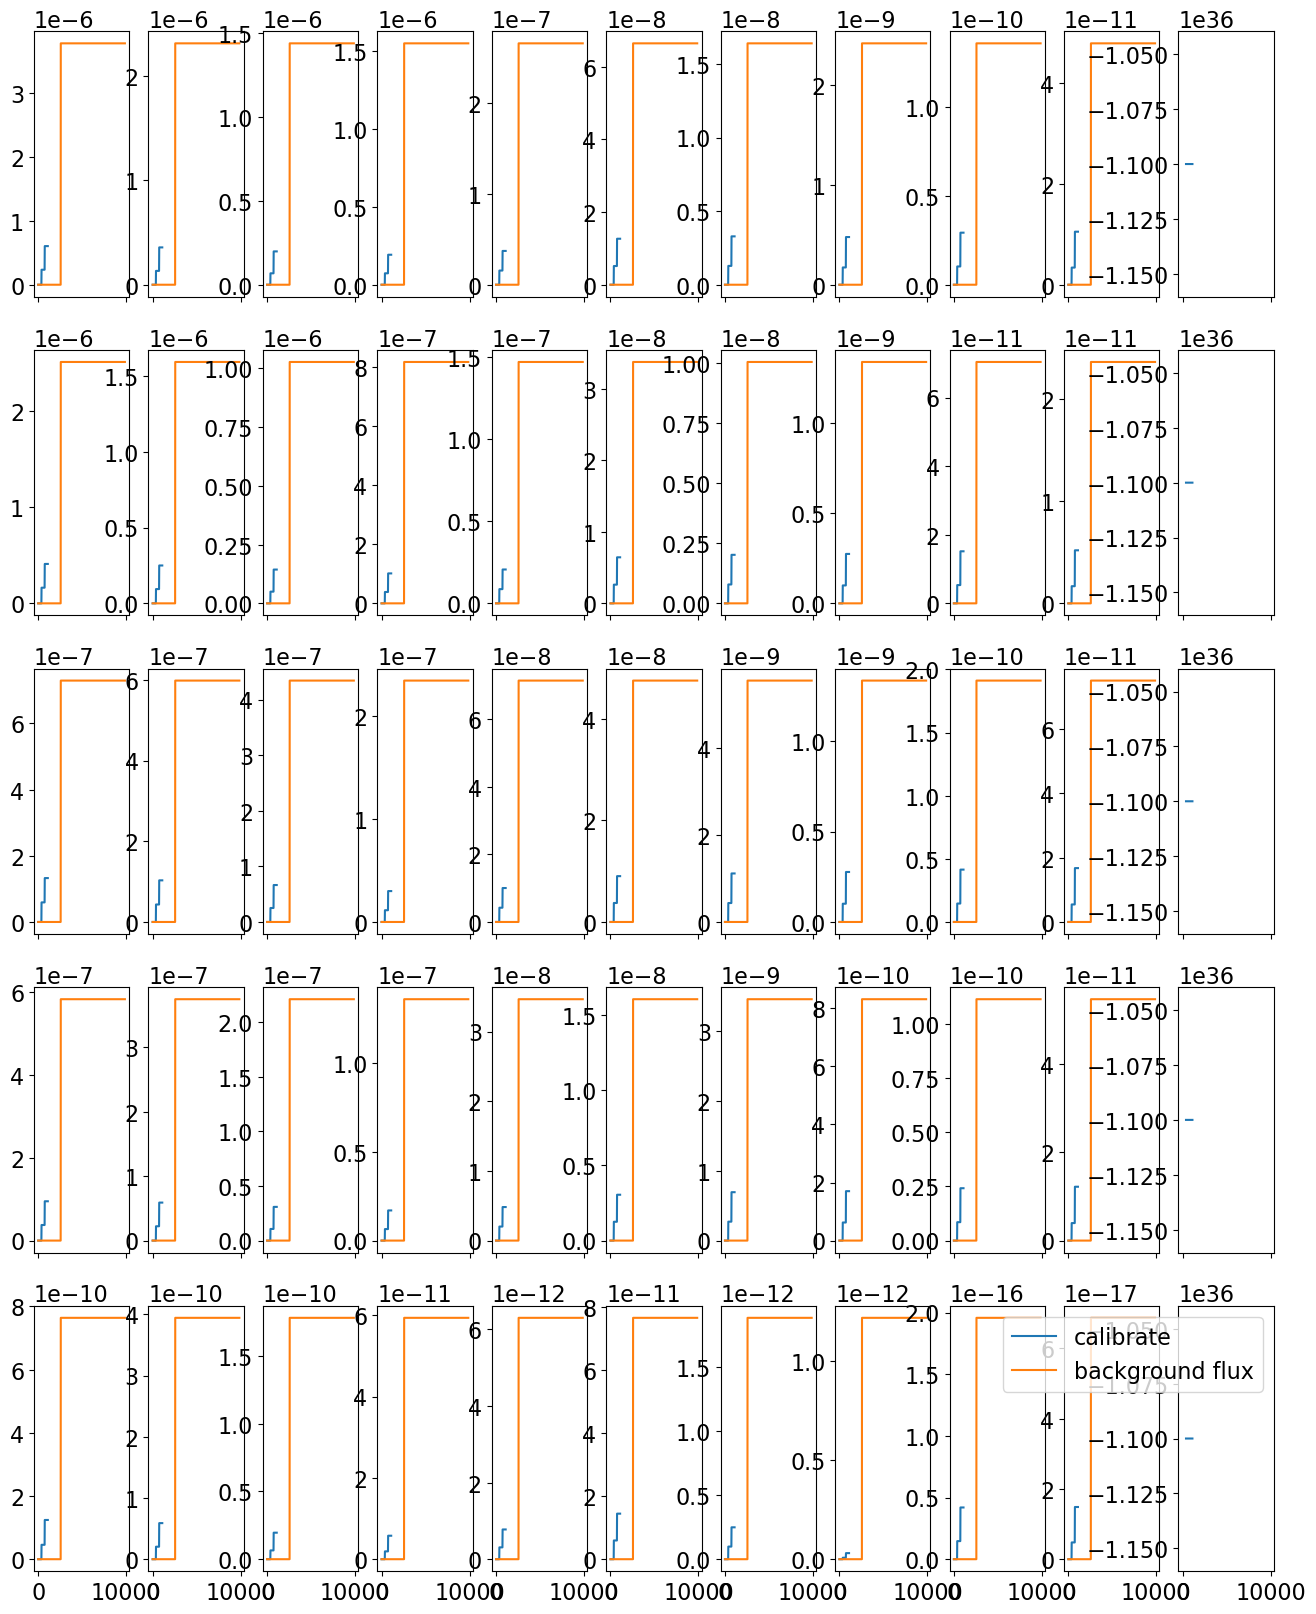

In [6]:
# Plot the replenishment

fig, axes = plt.subplots(5, 11, sharex = True, sharey = False, figsize = (16, 20))
for icat, cation in enumerate(['Ca2+','Mg2+','Na+','K+','Al3+']):
    for layer in range(11):
        ax = axes[icat, layer]

        ax.plot(-hr[f'annavg_cec_delta_vr_{icat+1}'][:1095, layer, 0].values, label = 'calibrate')
        ax.plot(hr[f'background_cec_vr_{icat+1}'][1095:, layer, 0].values, 
                label = 'background flux')

ax.legend()

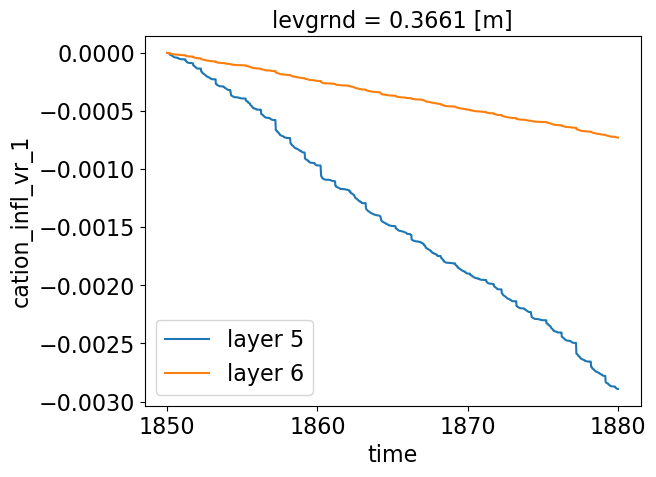

In [7]:
hr['cation_infl_vr_1'][:,4,0].cumsum().plot(), hr['cation_infl_vr_1'][:,5,0].cumsum().plot()
plt.legend(['layer 5', 'layer 6'])

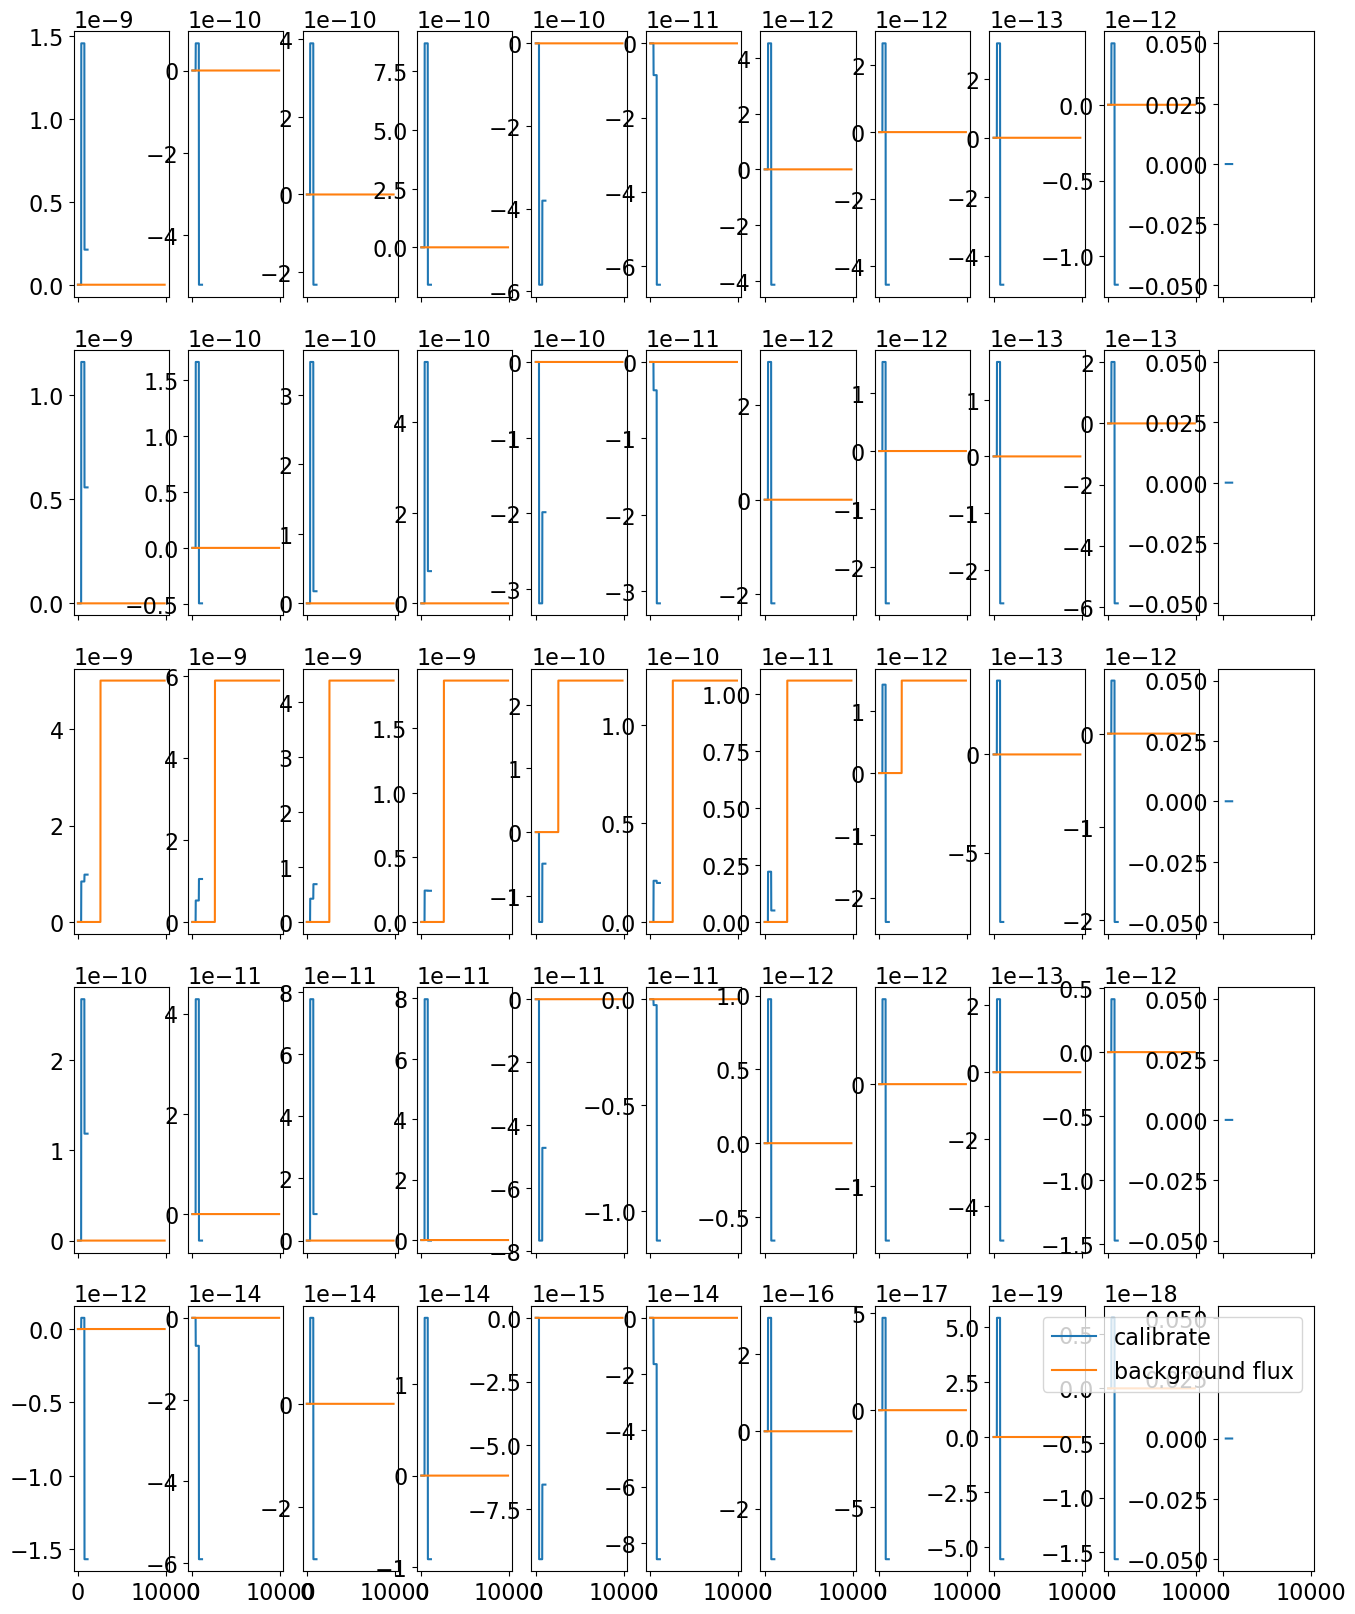

In [8]:
fig, axes = plt.subplots(5, 11, sharex = True, sharey = False, figsize = (16, 20))
for icat, cation in enumerate(['Ca2+','Mg2+','Na+','K+','Al3+']):
    for layer in range(11):
        ax = axes[icat, layer]

        temp = hr[f'annavg_cec_delta_vr_{icat+1}'][:1095, layer, 0].values - \
               hr[f'annavg_tot_delta_vr_{icat+1}'][:1095, layer, 0].values

        ax.plot(temp, label = 'calibrate')
        ax.plot(hr[f'background_flux_vr_{icat+1}'][1095:, layer, 0].values, 
                label = 'background flux')

ax.legend()